# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


✅ Dataset 'Housing_Data' Created Successfully!
Rows: 600, Columns: 6

--- Feature Breakdown ---
        Square_Feet    Bedrooms   Year_Built Neighborhood Renovation  \
count    600.000000  600.000000   600.000000          600        600   
unique          NaN         NaN          NaN            3          2   
top             NaN         NaN          NaN      Suburbs        Yes   
freq            NaN         NaN          NaN          306        326   
mean    2991.005000    2.938333  1986.821667          NaN        NaN   
std     1193.035793    1.433395    21.666000          NaN        NaN   
min      804.000000    1.000000  1950.000000          NaN        NaN   
25%     1953.000000    2.000000  1968.000000          NaN        NaN   
50%     2986.500000    3.000000  1987.000000          NaN        NaN   
75%     3993.750000    4.000000  2005.000000          NaN        NaN   
max     4999.000000    5.000000  2024.000000          NaN        NaN   

               Price  
count   6.000000

/tmp/ipykernel_74577/582618832.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='Price', data=df, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_74577/582618832.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Renovation', y='Price', data=df, ax=axes[1, 0], palette='coolwarm')


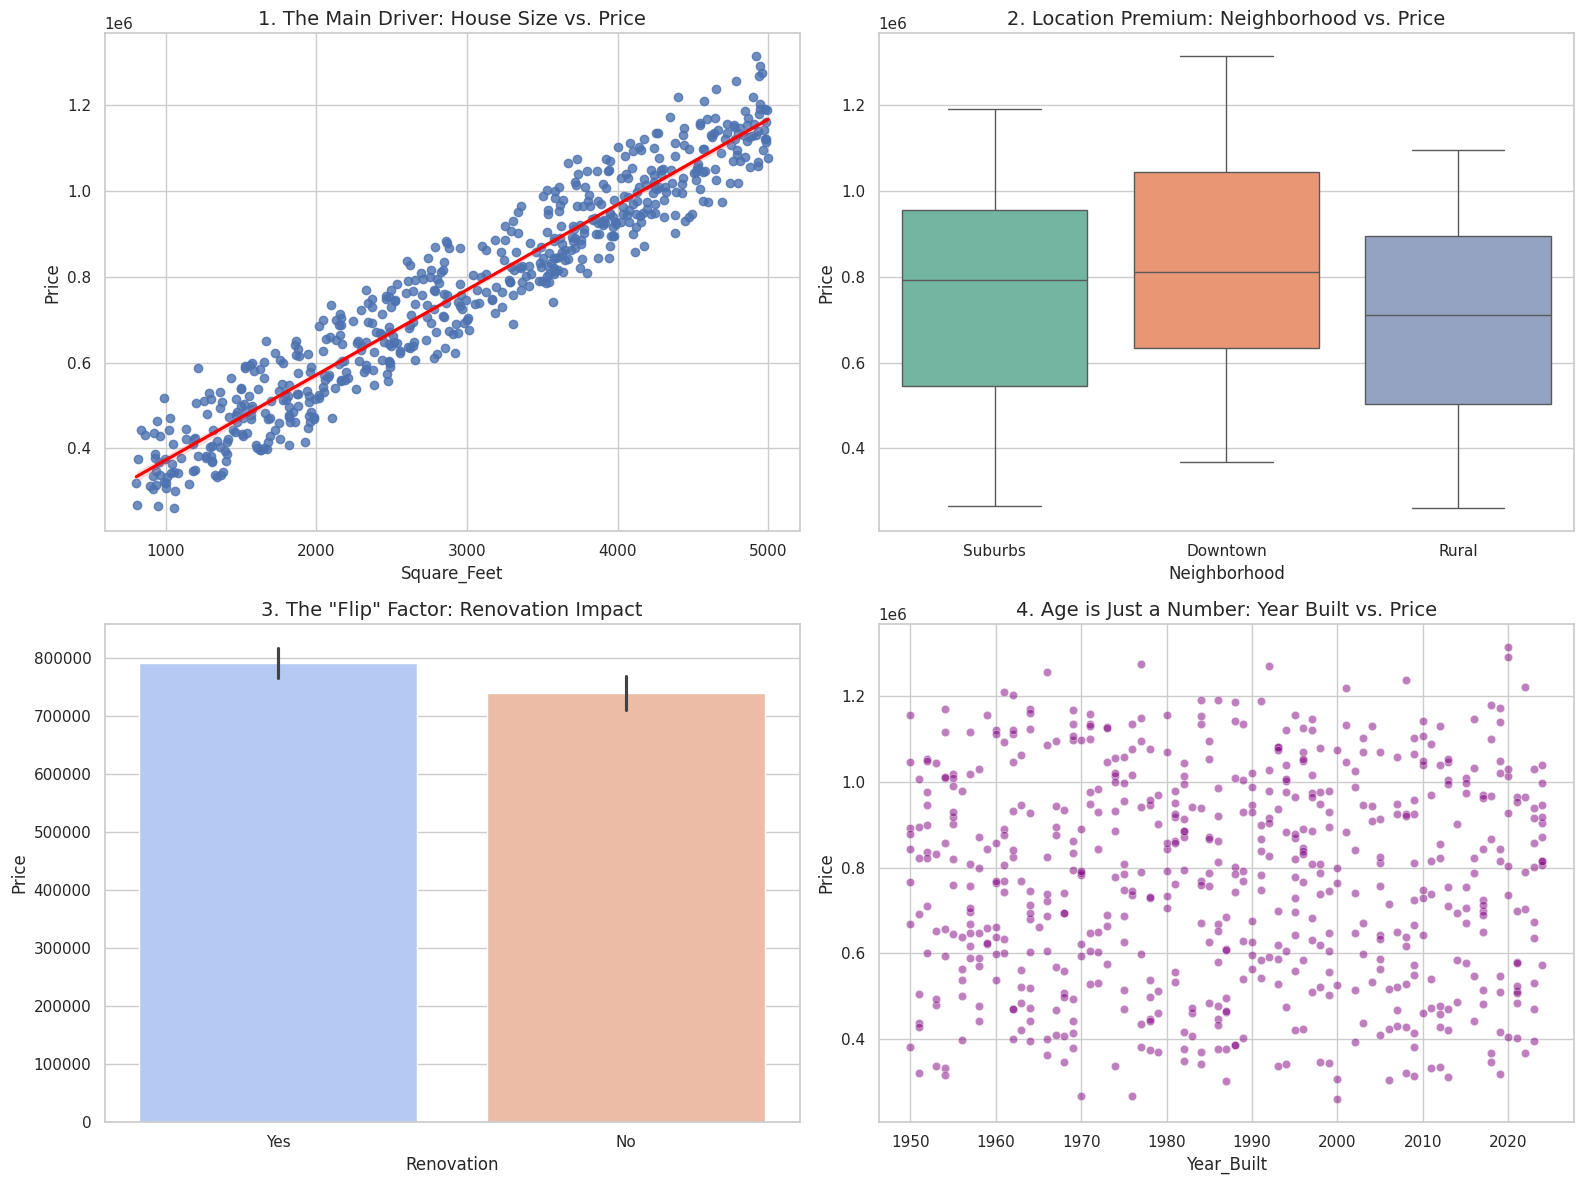


--- Statistical Correlation to Price ---
Price          1.000000
Square_Feet    0.960207
Bedrooms       0.045588
Year_Built    -0.003602
Name: Price, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: GENERATE THE DATASET (No CSV required!) ---
np.random.seed(42) # This makes sure the "random" numbers are the same every time
n_rows = 600

# We create the features mathematically
df = pd.DataFrame({
    'Square_Feet': np.random.randint(800, 5000, n_rows),
    'Bedrooms': np.random.randint(1, 6, n_rows),
    'Year_Built': np.random.randint(1950, 2025, n_rows),
    'Neighborhood': np.random.choice(['Downtown', 'Suburbs', 'Rural'], n_rows, p=[0.3, 0.5, 0.2]),
    'Renovation': np.random.choice(['Yes', 'No'], n_rows)
})

# We create the TARGET (Price) based on the features + some random noise
base_price = 50000
df['Price'] = (
    base_price + 
    (df['Square_Feet'] * 200) + 
    (df['Bedrooms'] * 10000) + 
    (np.where(df['Neighborhood'] == 'Downtown', 150000, np.where(df['Neighborhood'] == 'Suburbs', 50000, 0))) +
    (np.where(df['Renovation'] == 'Yes', 40000, 0)) +
    np.random.normal(0, 30000, n_rows)
)

# --- STEP 2: DESCRIBE THE DATA ---
print("✅ Dataset 'Housing_Data' Created Successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Feature Breakdown ---")
print(df.describe(include='all'))

# --- STEP 3: VISUALIZE THE RELATIONSHIPS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Viz 1: Size vs Price (The Strongest Driver)
sns.regplot(x='Square_Feet', y='Price', data=df, ax=axes[0, 0], line_kws={'color': 'red'})
axes[0, 0].set_title('1. The Main Driver: House Size vs. Price', fontsize=14)

# Viz 2: Location (Categorical)
sns.boxplot(x='Neighborhood', y='Price', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Location Premium: Neighborhood vs. Price', fontsize=14)

# Viz 3: Renovation Impact (Categorical)
sns.barplot(x='Renovation', y='Price', data=df, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('3. The "Flip" Factor: Renovation Impact', fontsize=14)

# Viz 4: Age (Weak Correlation)
sns.scatterplot(x='Year_Built', y='Price', data=df, ax=axes[1, 1], alpha=0.5, color='purple')
axes[1, 1].set_title('4. Age is Just a Number: Year Built vs. Price', fontsize=14)

plt.tight_layout()
plt.show()

# --- STEP 4: BIG PICTURE CONCLUSION ---
# Calculate correlation to prove our point
corr = df.select_dtypes(include='number').corr()['Price'].sort_values(ascending=False)
print("\n--- Statistical Correlation to Price ---")
print(corr)

Dataset Description:

"For this project, I analyzed a Real Estate Dataset containing 600 property records. The target variable is Price. The features include quantitative metrics like Square Feet and Bedrooms, as well as categorical features like Neighborhood (Downtown/Suburbs/Rural) and Renovation Status (Yes/No)."

Conclusion:

"The visualizations reveal that Square Footage is the single strongest predictor of a home's price, showing a clear linear relationship. Location is also a major driver, with 'Downtown' properties commanding a significant premium. Interestingly, Year Built showed the weakest correlation, suggesting that size and condition (Renovation) matter far more to buyers than the age of the building."